# Joint Controller and Understanding mjModel / mjData

A torque controller for the 7-DoF Franka Emika Panda, written from scratch in MuJoCo.

The controller itself is short. The point of the project is the layer underneath it: how MuJoCo stores state, which index maps to which joint, and where forces enter the equation of motion.

**Setup**

In [ ]:
%pip install mujoco matplotlib

In [ ]:
!git clone https://github.com/google-deepmind/mujoco_menagerie

## 1. Load the model and inspect its dimensions

`MjModel` holds everything static: link masses, joint limits, actuator definitions. `MjData` holds everything that changes as the simulation runs.

Three numbers describe the size of the problem:

- `nq` counts position coordinates in `qpos`
- `nv` counts degrees of freedom in `qvel`
- `nu` counts actuators in `ctrl`

For the Panda, `nq` and `nv` both equal 9 because all nine joints are hinge or slide joints with one DoF each. A robot with a free-floating base breaks that equality: its `qpos` stores a 4-component quaternion for orientation while `qvel` stores a 3-component angular velocity. Assuming `nq == nv` is the most common source of index bugs in MuJoCo code.

In [8]:
import time
import numpy as np
import mujoco
import mujoco.viewer
import matplotlib.pyplot as plt

XML = "mujoco_menagerie/franka_emika_panda/scene.xml"
model = mujoco.MjModel.from_xml_path(XML)
data = mujoco.MjData(model)

print(f"nq = {model.nq}   (qpos length)")
print(f"nv = {model.nv}   (qvel length, DoF count)")
print(f"nu = {model.nu}   (ctrl length, actuator count)")
print(f"timestep = {model.opt.timestep} s  ->  {1/model.opt.timestep:.0f} Hz physics")

nq = 9   (qpos length)
nv = 9   (qvel length, DoF count)
nu = 8   (ctrl length, actuator count)
timestep = 0.002 s  ->  500 Hz physics


## 2. Map joints to their slots in qpos and qvel

`jnt_qposadr[j]` gives the offset of joint `j` inside `qpos`. `jnt_dofadr[j]` gives its offset inside `qvel`. For the Panda both indices match the joint number, which will not hold once you move to a humanoid.

Note `joint4`: its range stops at -0.0698 rad, so the elbow can never straighten past that point. The solver enforces limits as constraints, so a controller that commands a target outside the range will fight the constraint and produce a steady-state error.

In [9]:
print(f"{'id':>3} {'joint name':<16} {'type':<8} {'qposadr':>8} {'dofadr':>7}   range")
for j in range(model.njnt):
    name = mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_JOINT, j)
    jtype = mujoco.mjtJoint(model.jnt_type[j]).name.replace("mjJNT_", "")
    lo, hi = model.jnt_range[j]
    print(f"{j:>3} {name:<16} {jtype:<8} {model.jnt_qposadr[j]:>8} "
          f"{model.jnt_dofadr[j]:>7}   [{lo:+.4f}, {hi:+.4f}]")

 id joint name       type      qposadr  dofadr   range
  0 joint1           HINGE           0       0   [-2.8973, +2.8973]
  1 joint2           HINGE           1       1   [-1.7628, +1.7628]
  2 joint3           HINGE           2       2   [-2.8973, +2.8973]
  3 joint4           HINGE           3       3   [-3.0718, -0.0698]
  4 joint5           HINGE           4       4   [-2.8973, +2.8973]
  5 joint6           HINGE           5       5   [-0.0175, +3.7525]
  6 joint7           HINGE           6       6   [-2.8973, +2.8973]
  7 finger_joint1    SLIDE           7       7   [+0.0000, +0.0400]
  8 finger_joint2    SLIDE           8       8   [+0.0000, +0.0400]


## 3. Map actuators to what they drive

Nine joints, eight actuators. The gripper fingers share one actuator through a tendon, so they always move together. `ctrl[7]` drives that tendon, not `joint8`.

`actuator_trntype` names the transmission: `JOINT` for the seven arm actuators, `TENDON` for the gripper. `actuator_trnid[:, 0]` gives the id of the target, and that id indexes into a different table depending on the transmission type. A tendon id of 0 and a joint id of 0 are unrelated objects.

Read `actuator_ctrlrange` for the gripper and you get [0, 255], which is neither radians nor newton-metres. The Menagerie model wraps the Franka gripper command in its own units. Never assume `ctrl` carries the units you expect.

In [10]:
print(f"{'id':>3} {'actuator':<12} {'transmission':<12} {'target':<16} ctrlrange")
for a in range(model.nu):
    name = mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_ACTUATOR, a)
    ttype = mujoco.mjtTrn(model.actuator_trntype[a]).name.replace("mjTRN_", "")
    tid = model.actuator_trnid[a, 0]
    if ttype == "JOINT":
        target = mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_JOINT, tid)
    elif ttype == "TENDON":
        target = mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_TENDON, tid)
    else:
        target = str(tid)
    lo, hi = model.actuator_ctrlrange[a]
    print(f"{a:>3} {name:<12} {ttype:<12} {target:<16} [{lo:.2f}, {hi:.2f}]")

 id actuator     transmission target           ctrlrange
  0 actuator1    JOINT        joint1           [-2.90, 2.90]
  1 actuator2    JOINT        joint2           [-1.76, 1.76]
  2 actuator3    JOINT        joint3           [-2.90, 2.90]
  3 actuator4    JOINT        joint4           [-3.07, -0.07]
  4 actuator5    JOINT        joint5           [-2.90, 2.90]
  5 actuator6    JOINT        joint6           [-0.02, 3.75]
  6 actuator7    JOINT        joint7           [-2.90, 2.90]
  7 actuator8    TENDON       split            [0.00, 255.00]


## 4. Read the keyframe and the built-in position servos

The Menagerie Panda ships with one keyframe named `home` and with position actuators already tuned. Each of those actuators runs a PD loop inside the solver: `gainprm[0]` is the proportional gain, `biasprm[2]` is the negated derivative gain. Actuator 1 uses kp = 4500, actuator 7 uses kp = 2000. Gains drop toward the wrist because the inertia the joint has to move drops as well.

Those servos will overwrite anything you do. Before writing your own controller you have to switch them off.

In [11]:
key_id = 0
print("keyframe:", mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_KEY, key_id))
print("key_qpos:", np.round(model.key_qpos[key_id], 4))
print("key_ctrl:", np.round(model.key_ctrl[key_id], 4))

print("\nbuilt-in servo gains (arm only):")
for a in range(7):
    kp = model.actuator_gainprm[a, 0]
    kd = -model.actuator_biasprm[a, 2]
    print(f"  actuator{a+1}: kp = {kp:7.1f}   kd = {kd:6.1f}")

print("\ndof_armature:", model.dof_armature)

keyframe: home
key_qpos: [ 0.      0.      0.     -1.5708  0.      1.5708 -0.7853  0.04    0.04  ]
key_ctrl: [  0.       0.       0.      -1.5708   0.       1.5708  -0.7853 255.    ]

built-in servo gains (arm only):
  actuator1: kp =  4500.0   kd =  450.0
  actuator2: kp =  4500.0   kd =  450.0
  actuator3: kp =  3500.0   kd =  350.0
  actuator4: kp =  3500.0   kd =  350.0
  actuator5: kp =  2000.0   kd =  200.0
  actuator6: kp =  2000.0   kd =  200.0
  actuator7: kp =  2000.0   kd =  200.0

dof_armature: [0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]


## 5. Switch the arm actuators off

Zeroing `gainprm` and `biasprm` for the first seven actuators turns them into no-ops. Their `ctrl` values stop producing force, and `qfrc_applied` becomes the only thing driving the arm. The gripper actuator stays live so the fingers hold their commanded width.

Editing the model in Python keeps the project to a single file. For a real project, copy `panda.xml`, replace the `<position>` block with `<motor>`, and set `ctrlrange` to the datasheet torque limits. That version also simulates actuator saturation, which the `qfrc_applied` route skips.

`dof_armature` from the previous cell matters here. It adds rotor inertia to the diagonal of the mass matrix and lets you run high gains without the integrator blowing up. Build your own MJCF without it and a controller that works on this notebook will explode.

In [12]:
NA = 7                 # actuated arm joints
ARM = slice(0, NA)

# Franka datasheet continuous torque limits, used later to clamp commands
TAU_MAX = np.array([87., 87., 87., 87., 12., 12., 12.])

def disable_arm_actuators(m):
    """Neutralise the built-in position servos on the 7 arm joints."""
    m.actuator_gainprm[:NA, :] = 0.0
    m.actuator_biasprm[:NA, :] = 0.0

disable_arm_actuators(model)

mujoco.mj_resetDataKeyframe(model, data, key_id)
Q_HOME = data.qpos[ARM].copy()
print("Q_HOME =", np.round(Q_HOME, 4))

Q_HOME = [ 0.      0.      0.     -1.5708  0.      1.5708 -0.7853]


## 6. Watch the arm collapse

With no control torque the arm falls. Verify that before adding anything, so you know the servos are off and gravity is doing what you expect.

Two functions advance the simulation and they do different jobs:

`mj_forward` computes derived quantities from the current `qpos` and `qvel`: Jacobians, the bias force, contact data. Simulation time does not move. Call it when you need kinematics without stepping.

`mj_step` runs `mj_forward` and then integrates one timestep. Time moves by `model.opt.timestep`.

The `time.sleep` call paces the loop against the wall clock. Drop it and 3000 steps finish in under a second with nothing visible on screen.

In [15]:
def run_viewer(steps, control_fn=None, decimation=1, realtime=True):
    """Open the passive viewer for a bounded number of physics steps."""
    mujoco.mj_resetDataKeyframe(model, data, key_id)
    data.qfrc_applied[:] = 0.0
    tau = np.zeros(NA)
    with mujoco.viewer.launch_passive(model, data) as viewer:
        for k in range(steps):
            wall = time.time()
            if control_fn is not None and k % decimation == 0:
                tau = control_fn(data.time)
            data.qfrc_applied[ARM] = tau
            mujoco.mj_step(model, data)
            viewer.sync()
            if realtime:
                remaining = model.opt.timestep - (time.time() - wall)
                if remaining > 0:
                    time.sleep(remaining)
    return data.qpos[ARM].copy()

q_end = run_viewer(steps=1500)          # 3 s of free fall
print("start:", np.round(Q_HOME, 3))
print("end:  ", np.round(q_end, 3))

start: [ 0.     0.     0.    -1.571  0.     1.571 -0.785]
end:   [ 0.27   1.763 -0.253 -0.228 -0.68   0.264 -0.886]


## 7. Gravity compensation

MuJoCo writes the equation of motion as

    M(q) qacc + qfrc_bias = qfrc_applied + actuator forces + constraint forces

`qfrc_bias` collects gravity, Coriolis and centrifugal terms. Setting `qfrc_applied = qfrc_bias` cancels all of them, and the arm holds any pose you drag it into.

This one line is the sharpest diagnostic in the project. If the arm still sags, your indices are wrong or the servos are still active. Fix that before writing a controller.

While the arm moves, `qfrc_bias` includes velocity-dependent terms, so this is not pure gravity compensation. Zero `qvel`, call `mj_forward`, and read `qfrc_bias` if you want gravity alone.

In [17]:
def gravity_compensation(t):
    mujoco.mj_forward(model, data)
    return data.qfrc_bias[ARM].copy()

q_end = run_viewer(steps=3000, control_fn=gravity_compensation)
drift = np.abs(q_end - Q_HOME).max()
print(f"max joint drift after 6 s: {drift:.2e} rad")
assert drift < 1e-6, "servos still active or index mismatch"

max joint drift after 6 s: 1.31e-14 rad


## 8. Inverse dynamics as a cross-check

`mj_inverse` solves the same equation in the other direction: give it `qpos`, `qvel` and a target `qacc`, and it returns the torque that produces that acceleration. Set `qacc` to zero and you recover the bias force.

The result feeds the computed-torque controller in the next section, and you will reach for it again when you build a task-space controller in a later project.

In [18]:
mujoco.mj_resetDataKeyframe(model, data, key_id)
mujoco.mj_forward(model, data)

data.qacc[:] = 0.0
mujoco.mj_inverse(model, data)
tau_inverse = data.qfrc_inverse[ARM].copy()
tau_bias = data.qfrc_bias[ARM].copy()

print("qfrc_inverse:", np.round(tau_inverse, 4))
print("qfrc_bias   :", np.round(tau_bias, 4))
print("max diff    :", np.abs(tau_inverse - tau_bias).max())

qfrc_inverse: [  0.     -29.356    0.      22.0492   0.6695   2.3064   0.    ]
qfrc_bias   : [  0.     -29.356    0.      22.0492   0.6695   2.3064   0.    ]
max diff    : 0.0


## 9. Reference trajectory

Every joint tracks a sine wave around its home position, amplitude 0.4 rad at 0.25 Hz. Slow enough to stay inside the joint limits, fast enough that a plain PD controller lags behind it.

The reference returns position, velocity and acceleration. The controller uses all three: position and velocity for feedback, acceleration for the feedforward term added later.

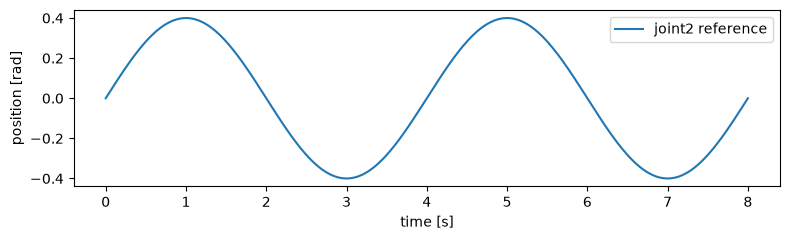

In [19]:
AMPLITUDE = 0.4      # rad
FREQUENCY = 0.25     # Hz

def reference(t):
    """Return desired position, velocity and acceleration at time t."""
    w = 2 * np.pi * FREQUENCY
    q_des = Q_HOME + AMPLITUDE * np.sin(w * t)
    dq_des = AMPLITUDE * w * np.cos(w * t)
    ddq_des = -AMPLITUDE * w * w * np.sin(w * t)
    return q_des, dq_des, ddq_des

t_grid = np.linspace(0, 8, 400)
plt.figure(figsize=(8, 2.5))
plt.plot(t_grid, [reference(t)[0][1] for t in t_grid], label="joint2 reference")
plt.xlabel("time [s]"); plt.ylabel("position [rad]"); plt.legend(); plt.tight_layout()
plt.show()

## 10. Three controllers

`pd` applies feedback alone. Gravity pulls the arm off the reference and the error never settles.

`gravity` adds `qfrc_bias`, which removes the steady offset. A phase lag remains, and it grows with trajectory frequency.

`feedforward` adds `M(q) ddq_des`, the torque needed to produce the commanded acceleration. `mj_mulM` multiplies by the mass matrix without ever forming it as a dense array, and it works across MuJoCo 3.x versions where the internal storage of `qM` has changed.

Gains follow the same pattern as the built-in servos: high at the base, low at the wrist. `kd = 2 sqrt(kp) zeta` sets a damping ratio of 0.7 for a unit-inertia joint, which is a starting point rather than a tuned value. If the arm chatters, lower `kp` before raising `kd`.

The clamp against `TAU_MAX` keeps commands inside the Franka torque envelope. Skip it and the controller will ask for torques no motor can deliver, which makes the simulation look better than the hardware ever will.

In [20]:
KP = np.array([600., 600., 600., 600., 250., 150., 50.])
KD = 2.0 * np.sqrt(KP) * 0.7

def make_controller(mode):
    """mode: 'pd' | 'gravity' | 'feedforward'"""
    def control(t):
        q_des, dq_des, ddq_des = reference(t)
        mujoco.mj_forward(model, data)

        tau = KP * (q_des - data.qpos[ARM]) + KD * (dq_des - data.qvel[ARM])

        if mode in ("gravity", "feedforward"):
            tau = tau + data.qfrc_bias[ARM]

        if mode == "feedforward":
            ddq = np.zeros(model.nv)
            ddq[ARM] = ddq_des
            inertial = np.zeros(model.nv)
            mujoco.mj_mulM(model, data, inertial, ddq)
            tau = tau + inertial[ARM]

        return np.clip(tau, -TAU_MAX, TAU_MAX)
    return control

## 11. Headless rollout and logging

The viewer is useful for a sanity check and useless for measurement. This loop runs without rendering, so eight seconds of simulation finish in well under a second, and it records position, reference and torque at every step.

`tracking_error` discards the first 30 % of the run so the startup transient does not pollute the numbers.

In [21]:
def rollout(mode, duration=8.0, decimation=1, gains=None):
    global KP, KD
    if gains is not None:
        KP, KD = gains

    control = make_controller(mode)
    mujoco.mj_resetDataKeyframe(model, data, key_id)
    data.qfrc_applied[:] = 0.0

    n_steps = int(duration / model.opt.timestep)
    tau = np.zeros(NA)
    log = {k: [] for k in ("t", "q", "q_des", "tau")}

    for k in range(n_steps):
        if k % decimation == 0:
            tau = control(data.time)
        data.qfrc_applied[ARM] = tau
        mujoco.mj_step(model, data)

        log["t"].append(data.time)
        log["q"].append(data.qpos[ARM].copy())
        log["q_des"].append(reference(data.time)[0])
        log["tau"].append(tau.copy())

    return {k: np.array(v) for k, v in log.items()}


def tracking_error(log, skip=0.3):
    i = int(len(log["t"]) * skip)
    err = log["q_des"][i:] - log["q"][i:]
    return np.abs(err).max(), np.sqrt((err ** 2).mean())


runs = {mode: rollout(mode) for mode in ("pd", "gravity", "feedforward")}

print(f"{'controller':<14} {'max err [rad]':>14} {'rms err [rad]':>14}")
for mode, log in runs.items():
    e_max, e_rms = tracking_error(log)
    print(f"{mode:<14} {e_max:>14.5f} {e_rms:>14.5f}")

controller      max err [rad]  rms err [rad]
pd                    0.07143        0.02372
gravity               0.01204        0.00388
feedforward           0.01194        0.00337


## 12. Plot the results

Look at joint 2 and joint 4, the two carrying the most gravity load.

Under `pd` the tracked curve sits below the reference through the whole run. Adding `qfrc_bias` closes most of that gap. Adding the inertial feedforward term cuts what remains of the phase lag, and the improvement grows as you raise `FREQUENCY`.

The torque plot is worth as much as the position plot. Read the peak values against `TAU_MAX` and you learn whether the controller you designed asks for something the hardware can deliver.

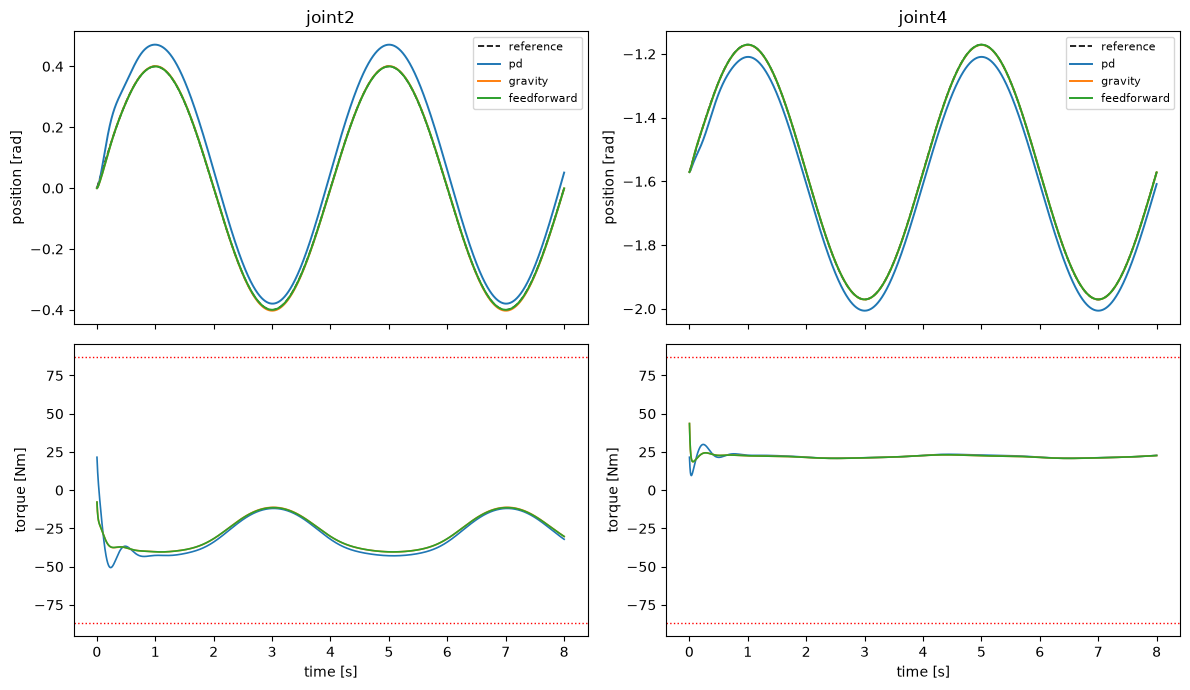

In [22]:
def plot_runs(runs, joints=(1, 3)):
    fig, axes = plt.subplots(2, len(joints), figsize=(6 * len(joints), 7), sharex=True)
    axes = np.atleast_2d(axes.reshape(2, -1))

    for col, j in enumerate(joints):
        ax = axes[0, col]
        ref = runs["feedforward"]
        ax.plot(ref["t"], ref["q_des"][:, j], "k--", lw=1.2, label="reference")
        for mode, log in runs.items():
            ax.plot(log["t"], log["q"][:, j], lw=1.4, label=mode)
        ax.set_title(f"joint{j+1}")
        ax.set_ylabel("position [rad]")
        ax.legend(fontsize=8)

        ax = axes[1, col]
        for mode, log in runs.items():
            ax.plot(log["t"], log["tau"][:, j], lw=1.2, label=mode)
        ax.axhline(TAU_MAX[j], color="r", ls=":", lw=1)
        ax.axhline(-TAU_MAX[j], color="r", ls=":", lw=1)
        ax.set_ylabel("torque [Nm]")
        ax.set_xlabel("time [s]")

    plt.tight_layout()
    plt.show()

plot_runs(runs)

## 13. Control rate and stability

Physics runs at 500 Hz. Real controllers run slower, so hold the torque constant across several physics steps and see what breaks. `decimation = 5` gives a 100 Hz control loop.

Gains tuned at 500 Hz do not survive the move to 100 Hz. The zero-order hold delays the damping term by up to one control period, and the feedback that damped the joint at 500 Hz starts to inject energy instead. Watch the error column climb and then blow past any sane value.

This is why a controller that behaves in simulation fails on hardware, and it costs nothing to discover here.

In [23]:
KP = np.array([600., 600., 600., 600., 250., 150., 50.])
KD = 2.0 * np.sqrt(KP) * 0.7

print(f"{'decimation':>10} {'rate [Hz]':>10} {'max err [rad]':>16}")
for dec in (1, 2, 3, 4, 5):
    log = rollout("feedforward", decimation=dec)
    e_max, _ = tracking_error(log)
    rate = 1 / (model.opt.timestep * dec)
    print(f"{dec:>10} {rate:>10.0f} {e_max:>16.5f}")

decimation  rate [Hz]    max err [rad]
         1        500          0.01194
         2        250          0.01194
         3        167          0.01194
         4        125          0.03877
         5        100          0.09677


## 14. Fixing it

Two ways out. Lower the gains until the loop is stable at the slower rate, or keep the gains and run the loop faster. The first costs tracking accuracy, the second costs compute.

Scaling `KP` by 0.35 brings the 100 Hz loop back under control with roughly three times the error of the 500 Hz version. That trade is the everyday reality of controller design on real hardware.

In [24]:
KP_SOFT = np.array([600., 600., 600., 600., 250., 150., 50.]) * 0.35
KD_SOFT = 2.0 * np.sqrt(KP_SOFT) * 0.7

log_soft = rollout("feedforward", decimation=5, gains=(KP_SOFT, KD_SOFT))
e_max, e_rms = tracking_error(log_soft)
print(f"100 Hz, softened gains -> max {e_max:.5f} rad, rms {e_rms:.5f} rad")

KP = np.array([600., 600., 600., 600., 250., 150., 50.])
KD = 2.0 * np.sqrt(KP) * 0.7

100 Hz, softened gains -> max 0.03088 rad, rms 0.00885 rad


## 15. Watch the finished controller

Back to the viewer with the feedforward controller and the original gains.

In [25]:
run_viewer(steps=4000, control_fn=make_controller("feedforward"))

array([-1.04547769e-03, -1.03791075e-03, -1.04564887e-03, -1.57182455e+00,
       -2.45386396e-03,  1.56675729e+00, -7.96535203e-01])